In [36]:
import os
from pathlib import Path
import numpy as np
from skimage import io, exposure
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image

import random
import matplotlib.pyplot as plt



In [53]:
from torchvision.transforms import Normalize
from skimage.color import rgb2gray
from skimage.filters import sobel, laplace, gaussian

In [40]:
# point BASE_DIR at the folder that holds “healthy/” and “deforested_clahe/”
BASE_DIR = Path(r"C:\Users\oliwa\Documents\capstone\images_for_modeling\combined_deforestation_drivers")

# sanity check
if not BASE_DIR.exists():
    raise FileNotFoundError(f"Could not find base directory: {BASE_DIR!r}")

In [41]:
for class_dir in BASE_DIR.iterdir():
    if not class_dir.is_dir() or class_dir.name.endswith("_clahe"):
        continue
    OUT_DIR = BASE_DIR / f"{class_dir.name}_clahe"
    OUT_DIR.mkdir(exist_ok=True)

    for img_path in class_dir.glob("*.png"):
        # load as float
        img = io.imread(str(img_path)).astype(np.float32)
        # only divide if in [0–255]
        if img.max() > 1.0:
            img /= 255.0

        clahe_img = np.zeros_like(img)
        for c in range(img.shape[2]):
            clahe_img[..., c] = exposure.equalize_adapthist(
                img[..., c], clip_limit=CLIP_LIMIT, nbins=NBINS
            )

        clahe_img = (np.clip(clahe_img, 0, 1) * 255).astype(np.uint8)
        if np.all(clahe_img == 255):
            continue

        io.imsave(str(OUT_DIR / img_path.name), clahe_img)





In [42]:
# 2) Build labels.csv & train/val split ---------------------------------------------
# Map each *_clahe folder to a numeric label
clahe_dirs = sorted(
    d for d in BASE_DIR.iterdir() if d.is_dir() and d.name.endswith("_clahe")
)
class_map = {d.name: idx for idx, d in enumerate(clahe_dirs)}

rows = []
for cls_name, label in class_map.items():
    folder = BASE_DIR / cls_name
    for img_path in folder.glob("*.png"):
        rows.append({"filepath": str(img_path), "label": label})

df = pd.DataFrame(rows)
labels_csv = BASE_DIR / "labels.csv"
df.to_csv(labels_csv, index=False)
print(f"Saved {len(df)} entries to {labels_csv}")

train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)
train_df.to_csv(BASE_DIR / "train_labels.csv", index=False)
val_df.to_csv(BASE_DIR / "val_labels.csv",   index=False)
print(f"Train samples: {len(train_df)} → train_labels.csv")
print(f" Val samples: {len(val_df)} → val_labels.csv")

# 3) Dataset + Edge‐channel Transform -----------------------------------------------
class CSVImageDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row["label"])
        return img, label

class AddEdgeLayersTorch:
    def __call__(self, img_tensor):
        # img_tensor: [3,H,W]
        # grayscale
        gray = img_tensor.mean(dim=0, keepdim=True).unsqueeze(0)  # [1,1,H,W]
        # define kernels
        sobel_x = torch.tensor([[[[-1,0,1],[-2,0,2],[-1,0,1]]]], dtype=torch.float32)
        sobel_y = torch.tensor([[[[-1,-2,-1],[0,0,0],[1,2,1]]]], dtype=torch.float32)
        laplace = torch.tensor([[[[0,1,0],[1,-4,1],[0,1,0]]]], dtype=torch.float32)
        # convolutions
        Gx  = F.conv2d(gray, sobel_x, padding=1)
        Gy  = F.conv2d(gray, sobel_y, padding=1)
        edge= torch.sqrt(Gx*Gx + Gy*Gy)
        log = F.conv2d(gray, laplace, padding=1)
        # normalize to [0,1]
        edge = (edge - edge.min())/(edge.max()-edge.min()+1e-6)
        log  = (log  - log.min())/(log.max()-log.min()+1e-6)
        edge = edge.squeeze(0)  # [1,H,W]
        log  = log .squeeze(0)  # [1,H,W]
        return torch.cat([img_tensor, edge, log], dim=0)  # [5,H,W]

# 4) Transforms & DataLoaders -------------------------------------------------------
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]
extra_mean    = [0.5, 0.5]
extra_std     = [0.5, 0.5]

edge_adder = AddEdgeLayersTorch()

train_transforms = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.2,0.2,0.2,0.1),
    T.ToTensor(),
    edge_adder,
    T.Normalize(mean=imagenet_mean + extra_mean,
                std= imagenet_std  + extra_std)
])
val_transforms = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    edge_adder,
    T.Normalize(mean=imagenet_mean + extra_mean,
                std= imagenet_std  + extra_std)
])

train_ds = CSVImageDataset(BASE_DIR/"train_labels.csv", transform=train_transforms)
val_ds   = CSVImageDataset(BASE_DIR/"val_labels.csv",   transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                          num_workers=0, pin_memory=True)



Saved 375 entries to C:\Users\oliwa\Documents\capstone\images_for_modeling\combined_deforestation_drivers\labels.csv
Train samples: 300 → train_labels.csv
 Val samples: 75 → val_labels.csv


In [43]:
# 5) Model setup -------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained MobileNetV3-Large
model = models.mobilenet_v3_large(pretrained=True)
# Adjust classifier for 5 classes
in_feats = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_feats, len(class_map))

# Rewire first conv to accept 5 channels
orig = model.features[0][0]
new_conv = nn.Conv2d(
    in_channels=5,
    out_channels=orig.out_channels,
    kernel_size=orig.kernel_size,
    stride=orig.stride,
    padding=orig.padding,
    bias=False
)
# copy RGB weights and init extra channels
new_conv.weight.data[:, :3, :, :] = orig.weight.data
nn.init.kaiming_normal_(new_conv.weight.data[:, 3:, :, :],
                        mode='fan_out', nonlinearity='relu')
model.features[0][0] = new_conv

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)




C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\oliwa\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [46]:
# 6) Training & Validation ---------------------------------------------------------
num_epochs = 20
for epoch in range(1, num_epochs+1):
    # --- training ---
    model.train()
    running_loss = 0.0
    for batch_idx, (imgs, labels) in enumerate(train_loader, 1):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if batch_idx % 10 == 0:
            avg = running_loss / 10
            print(f"Epoch {epoch} | Batch {batch_idx}/{len(train_loader)} | loss: {avg:.4f}")
            running_loss = 0.0

    # --- validation ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            val_loss += criterion(logits, labels).item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_loss /= total
    val_acc   = correct / total
    print(f"Epoch {epoch} → Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")


Epoch 1 | Batch 10/10 | loss: 0.3642
Epoch 1 → Val loss: 0.5383, Val acc: 0.8000
Epoch 2 | Batch 10/10 | loss: 0.2782
Epoch 2 → Val loss: 0.5023, Val acc: 0.8000
Epoch 3 | Batch 10/10 | loss: 0.2629
Epoch 3 → Val loss: 0.5221, Val acc: 0.8000
Epoch 4 | Batch 10/10 | loss: 0.2481
Epoch 4 → Val loss: 0.4557, Val acc: 0.8400
Epoch 5 | Batch 10/10 | loss: 0.3257
Epoch 5 → Val loss: 0.3997, Val acc: 0.8667
Epoch 6 | Batch 10/10 | loss: 0.2408
Epoch 6 → Val loss: 0.3905, Val acc: 0.8400
Epoch 7 | Batch 10/10 | loss: 0.2649
Epoch 7 → Val loss: 0.3759, Val acc: 0.8400
Epoch 8 | Batch 10/10 | loss: 0.2285
Epoch 8 → Val loss: 0.2877, Val acc: 0.8933
Epoch 9 | Batch 10/10 | loss: 0.1925
Epoch 9 → Val loss: 0.2983, Val acc: 0.8667
Epoch 10 | Batch 10/10 | loss: 0.2407
Epoch 10 → Val loss: 0.3687, Val acc: 0.8667
Epoch 11 | Batch 10/10 | loss: 0.1611
Epoch 11 → Val loss: 0.3558, Val acc: 0.8533
Epoch 12 | Batch 10/10 | loss: 0.2476
Epoch 12 → Val loss: 0.3918, Val acc: 0.8533
Epoch 13 | Batch 10/10

In [47]:
# 7) Final evaluation ----------------------------------------------------------------
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
print(f"Final validation accuracy: {correct/total:.4f}")



Final validation accuracy: 0.8800


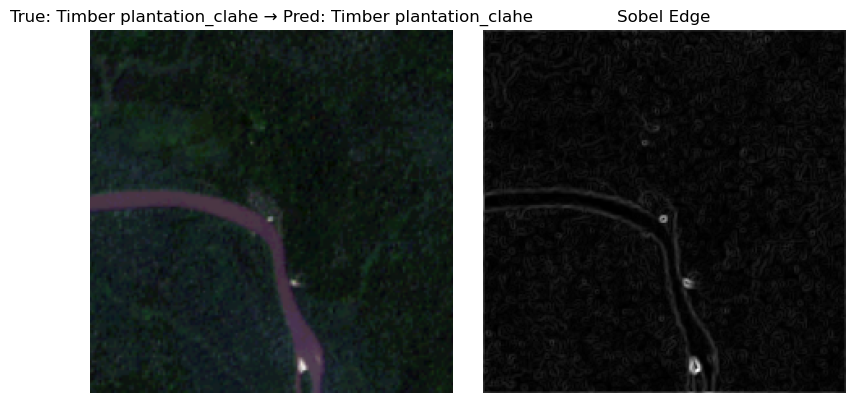

In [35]:
# 8) Visualize some predictions ------------------------------------------------------
class_names = [d.name for d in clahe_dirs]
idx = random.randint(0, len(val_ds)-1)
img_tensor, true_label = val_ds[idx]
model.eval()
with torch.no_grad():
    pred_idx = model(img_tensor.unsqueeze(0).to(device)).argmax(dim=1).item()

# prepare display
rgb = img_tensor[:3].clone()
for t, m, s in zip(rgb, imagenet_mean, imagenet_std):
    t.mul_(s).add_(m)
rgb = rgb.permute(1,2,0).cpu().numpy()
rgb_disp = np.clip(rgb * 255, 0, 255).astype(np.uint8)
edge = img_tensor[3].cpu().numpy()

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(8,4))
ax1.imshow(rgb_disp)
ax1.set_title(f"True: {class_names[true_label]} → Pred: {class_names[pred_idx]}")
ax1.axis("off")

ax2.imshow(edge, cmap="gray")
ax2.set_title("Sobel Edge")
ax2.axis("off")

plt.tight_layout()
plt.show()

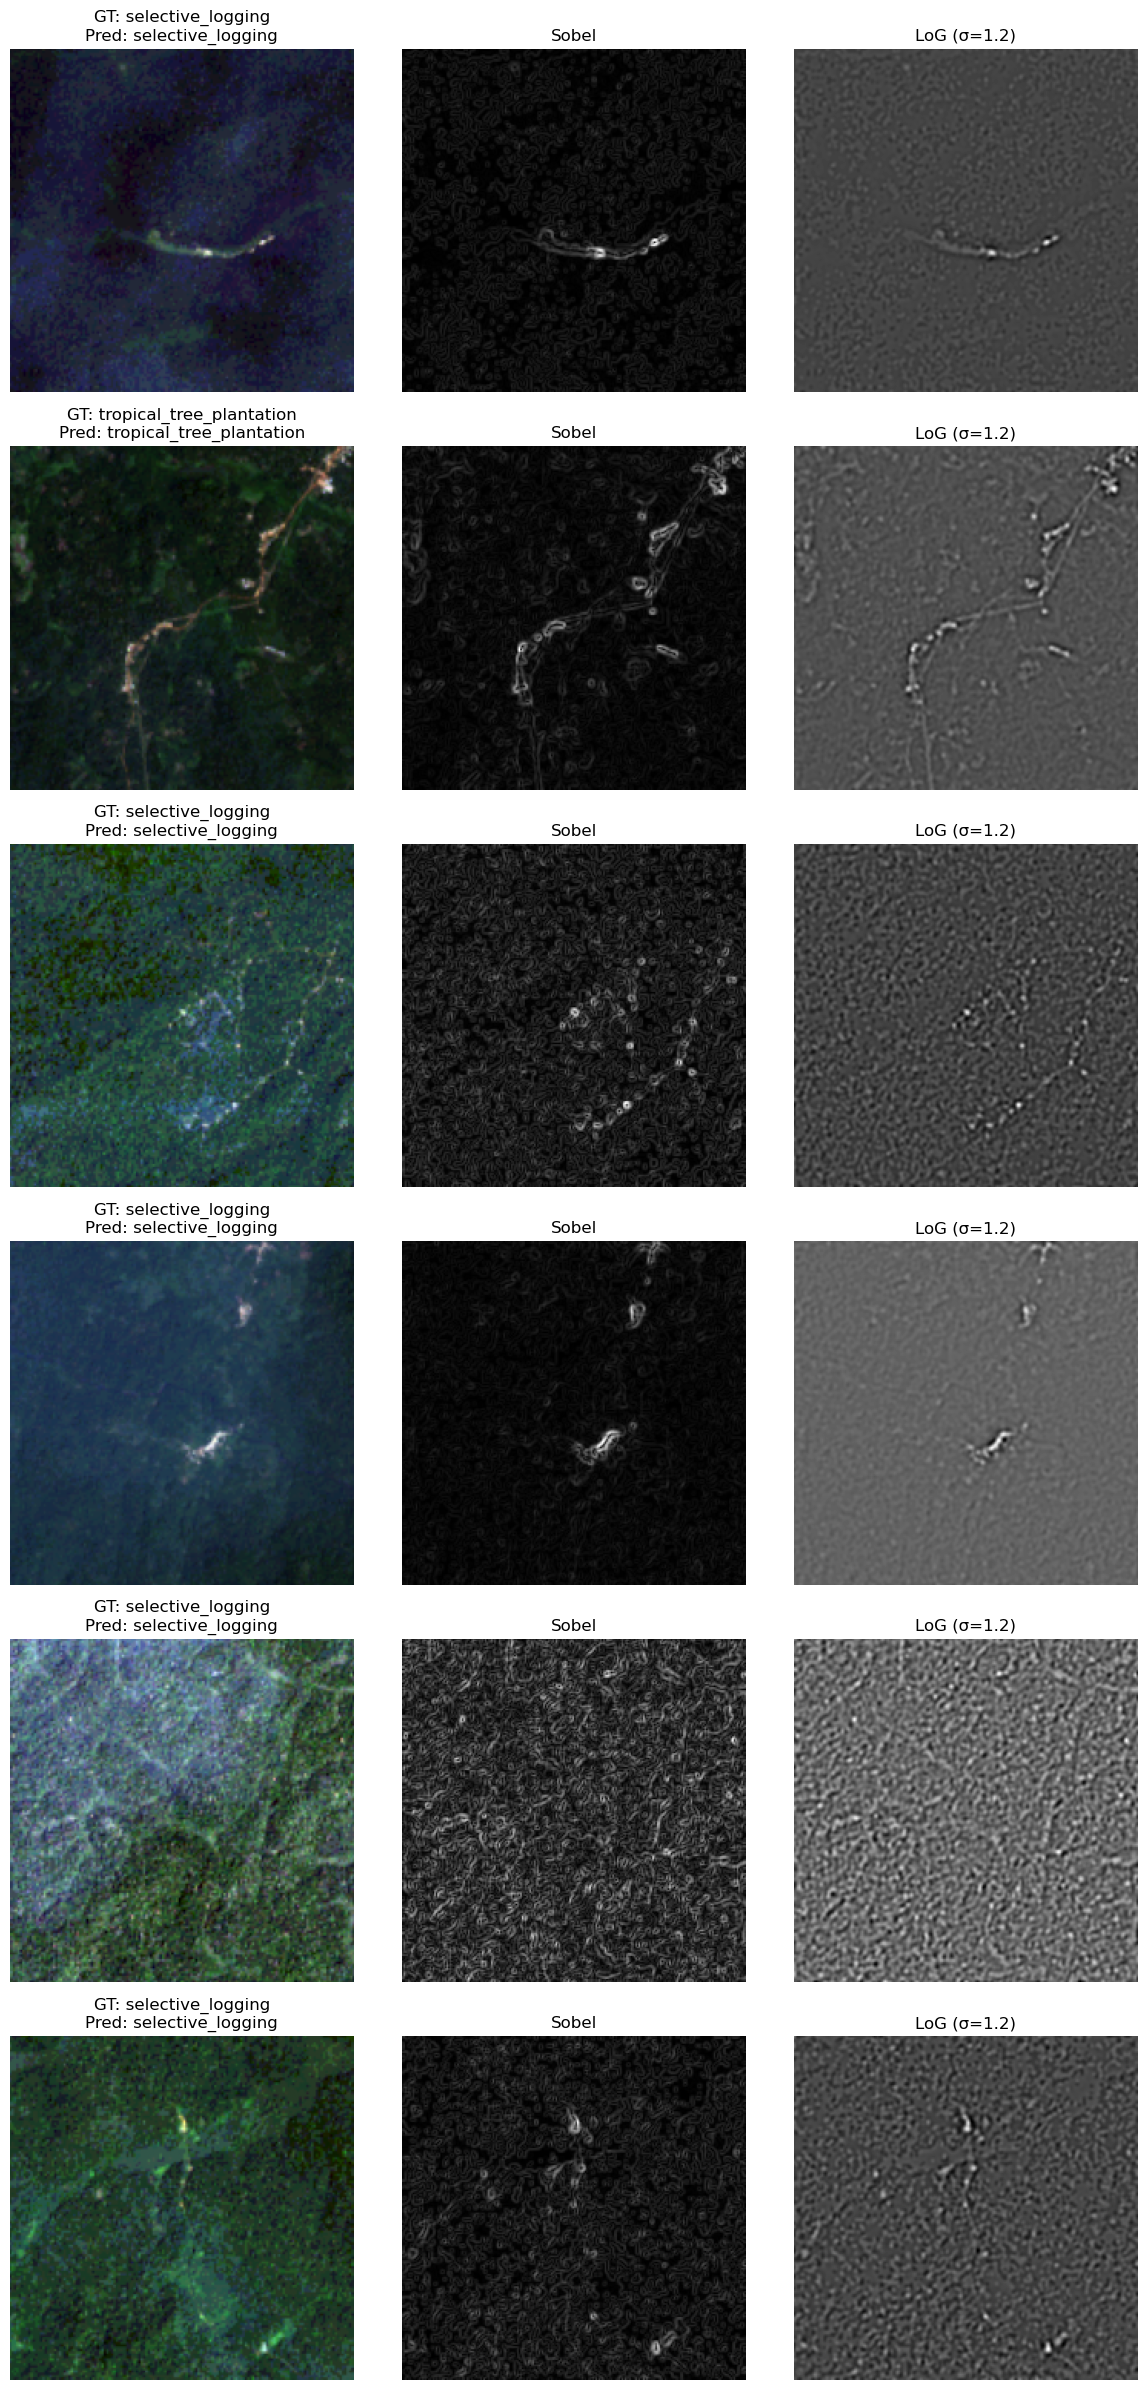

In [56]:
# ─── CONFIG ────────────────────────────────────────────────────────────────────
NUM_EXAMPLES = 6
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
inv_norm = Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std =[1/s   for s   in std]
)
LOG_SIGMA = 1.2
# ────────────────────────────────────────────────────────────────────────────────

# pull out your validation dataset
dataset   = val_loader.dataset
# get class names straight off your Dataset (works if you've set `self.classes = [...]`)
if hasattr(dataset, "classes"):
    class_names = dataset.classes
else:
    # fallback: manually list all your multiclass labels here in order
    class_names = ["maize_plantation", "selective_logging", "tropical_tree_plantation", "wildfire"]  

# sample some random indices
indices = random.sample(range(len(dataset)), min(NUM_EXAMPLES, len(dataset)))

# set up the grid: NUM_EXAMPLES rows × 3 cols
fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))

model.eval()
with torch.no_grad():
    for row, idx in enumerate(indices):
        img_tensor, true_label = dataset[idx]       # shape [C, H, W]
        # --- RGB display (first 3 bands) ----------------------------
        rgb_disp = (
            inv_norm(img_tensor[:3])
            .permute(1, 2, 0)                         # [H, W, 3]
            .clamp(0, 1)
            .cpu()
            .numpy()
        )
        gray      = rgb2gray(rgb_disp)

        # --- Edge maps ----------------------------------------------
        sobel_map = sobel(gray)
        log_map   = laplace(gaussian(gray, sigma=LOG_SIGMA))

        # --- Model prediction ---------------------------------------
        logits   = model(img_tensor.unsqueeze(0).to(device))
        pred_idx = logits.argmax(dim=1).item()

        # --- Plot ----------------------------------------------------
        ax_rgb, ax_sobel, ax_log = axes[row]
        ax_rgb.imshow(rgb_disp)
        ax_rgb.set_title(f"GT: {class_names[true_label]}\nPred: {class_names[pred_idx]}")
        ax_rgb.axis("off")

        ax_sobel.imshow(sobel_map, cmap="gray")
        ax_sobel.set_title("Sobel")
        ax_sobel.axis("off")

        ax_log.imshow(log_map, cmap="gray")
        ax_log.set_title(f"LoG (σ={LOG_SIGMA})")
        ax_log.axis("off")

plt.tight_layout()
plt.show()